## **Environment Setup and Library Imports**

In [1]:
!pip install yfinance ta -q

  Preparing metadata (setup.py) ... done


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import copy
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
from ta.momentum import RSIIndicator, StochasticOscillator
from ta.trend import MACD, SMAIndicator, EMAIndicator
from ta.volatility import BollingerBands, AverageTrueRange

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## **Data Collection and Initial Preprocessing**

In [3]:
ticker = "SPY"
start_date = "2010-01-01"
end_date = "2025-01-01"

df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
df = df.reset_index()

if isinstance(df.columns, pd.MultiIndex):
    df.columns = [col[0] if col[1] == "" else col[0] for col in df.columns]

df = df[["Date", "Open", "High", "Low", "Close", "Volume"]].copy()
df.dropna(inplace=True)
df.sort_values("Date", inplace=True)
df.reset_index(drop=True, inplace=True)

print(df.head())
print(df.shape)

[*********************100%***********************]  1 of 1 completed

        Date       Open       High        Low      Close     Volume
0 2010-01-04  84.078076  84.841263  83.434602  84.796371  118944600
1 2010-01-05  84.744011  85.058265  84.437236  85.020851  111579900
2 2010-01-06  84.938562  85.290229  84.871224  85.080727  116074400
3 2010-01-07  84.923580  85.544609  84.684148  85.439857  131091100
4 2010-01-08  85.215419  85.761626  85.043330  85.724213  126402800
(3774, 6)


# **Feature Engineering**

In [4]:
def add_features(data):
    data = data.copy()

    data["ret_1"] = data["Close"].pct_change(1)
    data["ret_3"] = data["Close"].pct_change(3)
    data["ret_5"] = data["Close"].pct_change(5)
    data["ret_10"] = data["Close"].pct_change(10)

    data["oc_change"] = (data["Close"] - data["Open"]) / data["Open"]
    data["hl_range"] = (data["High"] - data["Low"]) / data["Close"]
    data["co_gap"] = (data["Open"] - data["Close"].shift(1)) / data["Close"].shift(1)

    data["vol_chg_1"] = data["Volume"].pct_change(1)
    data["vol_chg_5"] = data["Volume"].pct_change(5)

    data["sma_5"] = SMAIndicator(data["Close"], window=5).sma_indicator()
    data["sma_10"] = SMAIndicator(data["Close"], window=10).sma_indicator()
    data["sma_20"] = SMAIndicator(data["Close"], window=20).sma_indicator()
    data["ema_10"] = EMAIndicator(data["Close"], window=10).ema_indicator()
    data["ema_20"] = EMAIndicator(data["Close"], window=20).ema_indicator()

    data["close_sma5_ratio"] = data["Close"] / data["sma_5"]
    data["close_sma10_ratio"] = data["Close"] / data["sma_10"]
    data["close_sma20_ratio"] = data["Close"] / data["sma_20"]
    data["ema10_ema20_ratio"] = data["ema_10"] / data["ema_20"]

    data["rsi_14"] = RSIIndicator(close=data["Close"], window=14).rsi()

    stoch = StochasticOscillator(
        high=data["High"],
        low=data["Low"],
        close=data["Close"],
        window=14,
        smooth_window=3
    )
    data["stoch_k"] = stoch.stoch()
    data["stoch_d"] = stoch.stoch_signal()

    macd = MACD(close=data["Close"], window_slow=26, window_fast=12, window_sign=9)
    data["macd"] = macd.macd()
    data["macd_signal"] = macd.macd_signal()
    data["macd_diff"] = macd.macd_diff()

    bb = BollingerBands(close=data["Close"], window=20, window_dev=2)
    data["bb_high"] = bb.bollinger_hband()
    data["bb_low"] = bb.bollinger_lband()
    data["bb_width"] = (data["bb_high"] - data["bb_low"]) / data["Close"]

    atr = AverageTrueRange(
        high=data["High"],
        low=data["Low"],
        close=data["Close"],
        window=14
    )
    data["atr_14"] = atr.average_true_range()
    data["atr_close_ratio"] = data["atr_14"] / data["Close"]

    data["volatility_10"] = data["ret_1"].rolling(10).std()
    data["volatility_20"] = data["ret_1"].rolling(20).std()

    return data

In [5]:
df = add_features(df)
print(df.head())
print(df.shape)
df.info()

        Date       Open       High        Low      Close     Volume     ret_1  \
0 2010-01-04  84.078076  84.841263  83.434602  84.796371  118944600       NaN   
1 2010-01-05  84.744011  85.058265  84.437236  85.020851  111579900  0.002647   
2 2010-01-06  84.938562  85.290229  84.871224  85.080727  116074400  0.000704   
3 2010-01-07  84.923580  85.544609  84.684148  85.439857  131091100  0.004221   
4 2010-01-08  85.215419  85.761626  85.043330  85.724213  126402800  0.003328   

      ret_3  ret_5  ret_10  ...  macd  macd_signal  macd_diff  bb_high  \
0       NaN    NaN     NaN  ...   NaN          NaN        NaN      NaN   
1       NaN    NaN     NaN  ...   NaN          NaN        NaN      NaN   
2       NaN    NaN     NaN  ...   NaN          NaN        NaN      NaN   
3  0.007589    NaN     NaN  ...   NaN          NaN        NaN      NaN   
4  0.008273    NaN     NaN  ...   NaN          NaN        NaN      NaN   

   bb_low  bb_width  atr_14  atr_close_ratio  volatility_10  volatil

# **Target Variable Creation**

In [7]:
horizon = 5
neutral_band = 0.002   # 0.2% dead zone

df["forward_return_5d"] = df["Close"].shift(-horizon) / df["Close"] - 1

# Removing tiny movements around zero to make classes more learnable
df = df[(df["forward_return_5d"].abs() >= neutral_band)].copy()

# Binary target
df["Target"] = (df["forward_return_5d"] > 0).astype(int)

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(df[["Date", "Close", "forward_return_5d", "Target"]].head())
print("\nClass distribution:")
print(df["Target"].value_counts())
print(df["Target"].value_counts(normalize=True))

        Date      Close  forward_return_5d  Target
0 2010-02-22  83.172737           0.006567       1
1 2010-02-23  82.162605           0.021765       1
2 2010-02-24  82.918327           0.013355       1
3 2010-02-25  82.806076           0.017801       1
4 2010-02-26  82.858459           0.031696       1

Class distribution:
Target
1    2112
0    1266
Name: count, dtype: int64
Target
1    0.625222
0    0.374778
Name: proportion, dtype: float64


## **Feature Selection**

In [8]:
feature_cols = [
    "Open", "High", "Low", "Close", "Volume",
    "ret_1", "ret_3", "ret_5", "ret_10",
    "oc_change", "hl_range", "co_gap",
    "vol_chg_1", "vol_chg_5",
    "close_sma5_ratio", "close_sma10_ratio", "close_sma20_ratio",
    "ema10_ema20_ratio",
    "rsi_14", "stoch_k", "stoch_d",
    "macd", "macd_signal", "macd_diff",
    "bb_width", "atr_close_ratio",
    "volatility_10", "volatility_20"
]

target_col = "Target"
print("Number of features:", len(feature_cols))

Number of features: 28


# **Train, validation and test split**

In [9]:
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

Train: (2364, 39)
Val  : (507, 39)
Test : (507, 39)


# **Data Normalization**

In [10]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_df[feature_cols])
val_scaled = scaler.transform(val_df[feature_cols])
test_scaled = scaler.transform(test_df[feature_cols])

train_scaled = pd.DataFrame(train_scaled, columns=feature_cols, index=train_df.index)
val_scaled = pd.DataFrame(val_scaled, columns=feature_cols, index=val_df.index)
test_scaled = pd.DataFrame(test_scaled, columns=feature_cols, index=test_df.index)

print(train_scaled.head())

       Open      High       Low     Close    Volume     ret_1     ret_3  \
0 -1.418312 -1.424914 -1.419208 -1.423356  0.058177 -0.020129  0.378691   
1 -1.426612 -1.429461 -1.435055 -1.439596  1.047008 -1.119350 -0.621374   
2 -1.435272 -1.431854 -1.430942 -1.427446  0.637183  0.784171 -0.232074   
3 -1.446098 -1.434846 -1.442072 -1.429251  1.733040 -0.156905 -0.316640   
4 -1.427694 -1.430418 -1.427918 -1.428409  0.600848  0.020254  0.395647   

      ret_5    ret_10  oc_change  ...    rsi_14   stoch_k   stoch_d      macd  \
0  1.161094  1.220605  -0.457190  ... -0.036289  0.972673  1.083498 -0.346658   
1 -0.071127  1.052918  -1.210635  ... -0.610105  0.331717  0.821079 -0.333395   
2  0.122665  0.941245   0.762161  ... -0.221571  0.811243  0.764381 -0.293993   
3 -0.193356  0.961551   1.634291  ... -0.285616  0.740017  0.680034 -0.266457   
4 -0.255998  0.635169  -0.050490  ... -0.257245  0.688238  0.809287 -0.242483   

   macd_signal  macd_diff  bb_width  atr_close_ratio  volatili

# **Sequence Creation for Time-Series Modeling**

In [11]:
sequence_length = 30

def make_sequences(feature_df, original_df, feature_columns, target_column, seq_len):
    X, y, dates, future_returns, vols = [], [], [], [], []

    values = feature_df[feature_columns].values
    targets = original_df[target_column].values
    date_vals = original_df["Date"].values
    fwd_ret_vals = original_df["forward_return_5d"].values
    vol_vals = original_df["volatility_20"].values

    for i in range(seq_len, len(feature_df)):
        X.append(values[i-seq_len:i])
        y.append(targets[i])
        dates.append(date_vals[i])
        future_returns.append(fwd_ret_vals[i])
        vols.append(vol_vals[i])

    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32),
        np.array(dates),
        np.array(future_returns, dtype=np.float32),
        np.array(vols, dtype=np.float32)
    )

In [12]:
X_train, y_train, train_dates, train_fwd, train_vol = make_sequences(
    train_scaled, train_df, feature_cols, target_col, sequence_length
)

X_val, y_val, val_dates, val_fwd, val_vol = make_sequences(
    val_scaled, val_df, feature_cols, target_col, sequence_length
)

X_test, y_test, test_dates, test_fwd, test_vol = make_sequences(
    test_scaled, test_df, feature_cols, target_col, sequence_length
)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (2334, 30, 28) y_train: (2334,)
X_val  : (477, 30, 28) y_val  : (477,)
X_test : (477, 30, 28) y_test : (477,)


# **Dataset and DataLoader Preparation**

In [13]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [14]:
batch_size = 32

train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset = TimeSeriesDataset(X_val, y_val)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Dataloaders ready.")

Dataloaders ready.


# **Model Architectures**

In [15]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [16]:
# Define LSTM
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        logits = self.fc(out)
        return logits

In [17]:
# Define Transformer Classifier
class TransformerClassifier(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model=d_model, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, 2)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        out = self.transformer(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        logits = self.fc(out)
        return logits

In [18]:
# Define Hybrid LSTM Transformer classifier
class HybridLSTMTransformerClassifier(nn.Module):
    def __init__(
        self,
        input_dim,
        lstm_hidden=64,
        lstm_layers=1,
        d_model=64,
        nhead=4,
        transformer_layers=1,
        dim_feedforward=128,
        dropout=0.3
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=0.0 if lstm_layers == 1 else dropout
        )

        self.proj = nn.Linear(lstm_hidden, d_model)
        self.pos_encoder = PositionalEncoding(d_model=d_model, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=transformer_layers)

        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(d_model, 32)
        self.fc2 = nn.Linear(32, 2)
        self.act = nn.ReLU()

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x = self.proj(lstm_out)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = x[:, -1, :]
        x = self.dropout(x)
        x = self.act(self.fc1(x))
        logits = self.fc2(x)
        return logits

# **Training Pipeline, Optimization, and Evaluation Utilities**

In [19]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_recall_fscore_support

# Computing class weights from training labels
classes = np.array([0, 1])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train.astype(int)
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:", class_weights)

def evaluate_loss(model, loader, criterion):
    model.eval()
    losses = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.long().to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            losses.append(loss.item())

    return np.mean(losses)

def train_model(model, train_loader, val_loader, epochs=40, lr=5e-4, weight_decay=1e-4, patience=10):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    patience_counter = 0

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.long().to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = np.mean(train_losses)
        val_loss = evaluate_loss(model, val_loader, criterion)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_model_wts)
    return model, history

def get_probabilities(model, loader):
    model.eval()
    probs = []
    labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            batch_probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

            probs.extend(batch_probs)
            labels.extend(y_batch.numpy())

    return np.array(probs), np.array(labels)

def tune_threshold_macro_f1(y_true, probs):
    thresholds = np.arange(0.35, 0.66, 0.01)
    best_threshold = 0.50
    best_score = -1

    for thr in thresholds:
        preds = (probs >= thr).astype(int)
        score = f1_score(y_true, preds, average="macro", zero_division=0)
        if score > best_score:
            best_score = score
            best_threshold = thr

    return best_threshold, best_score

def compute_metrics(y_true, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, preds, labels=[0, 1], zero_division=0
    )

    results = {
        "Accuracy": accuracy_score(y_true, preds),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, preds),
        "Macro_F1": f1_score(y_true, preds, average="macro", zero_division=0),
        "Weighted_F1": f1_score(y_true, preds, average="weighted", zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, probs),

        "Precision_Class_0": precision[0],
        "Recall_Class_0": recall[0],
        "F1_Class_0": f1[0],

        "Precision_Class_1": precision[1],
        "Recall_Class_1": recall[1],
        "F1_Class_1": f1[1]
    }

    return results, preds

def plot_history(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    plt.xticks([0, 1], ["Down/Flat", "Up"])
    plt.yticks([0, 1], ["Down/Flat", "Up"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

Class weights: [1.33830275 0.79822161]


In [20]:
# Model Initialization and Configuration
input_dim = len(feature_cols)

models = {
    "LSTM": LSTMClassifier(
        input_dim=input_dim,
        hidden_dim=64,
        num_layers=1,
        dropout=0.2
    ),
    "Transformer": TransformerClassifier(
        input_dim=input_dim,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.2
    ),
    "Hybrid_LSTM_Transformer": HybridLSTMTransformerClassifier(
        input_dim=input_dim,
        lstm_hidden=64,
        lstm_layers=1,
        d_model=64,
        nhead=4,
        transformer_layers=1,
        dim_feedforward=128,
        dropout=0.2
    )
}

print(models.keys())

dict_keys(['LSTM', 'Transformer', 'Hybrid_LSTM_Transformer'])



Training LSTM
Epoch 01 | Train Loss: 0.6943 | Val Loss: 0.6997
Epoch 02 | Train Loss: 0.6896 | Val Loss: 0.7016
Epoch 03 | Train Loss: 0.6863 | Val Loss: 0.6964
Epoch 04 | Train Loss: 0.6834 | Val Loss: 0.6902
Epoch 05 | Train Loss: 0.6764 | Val Loss: 0.6964
Epoch 06 | Train Loss: 0.6718 | Val Loss: 0.6981
Epoch 07 | Train Loss: 0.6646 | Val Loss: 0.6889
Epoch 08 | Train Loss: 0.6578 | Val Loss: 0.6980
Epoch 09 | Train Loss: 0.6477 | Val Loss: 0.7093
Epoch 10 | Train Loss: 0.6305 | Val Loss: 0.7296
Epoch 11 | Train Loss: 0.6121 | Val Loss: 0.7717
Epoch 12 | Train Loss: 0.5877 | Val Loss: 0.8253
Epoch 13 | Train Loss: 0.5721 | Val Loss: 0.8543
Epoch 14 | Train Loss: 0.5627 | Val Loss: 0.8463
Epoch 15 | Train Loss: 0.5480 | Val Loss: 0.8659
Epoch 16 | Train Loss: 0.5363 | Val Loss: 0.9068
Epoch 17 | Train Loss: 0.5209 | Val Loss: 0.9122
Early stopping triggered.


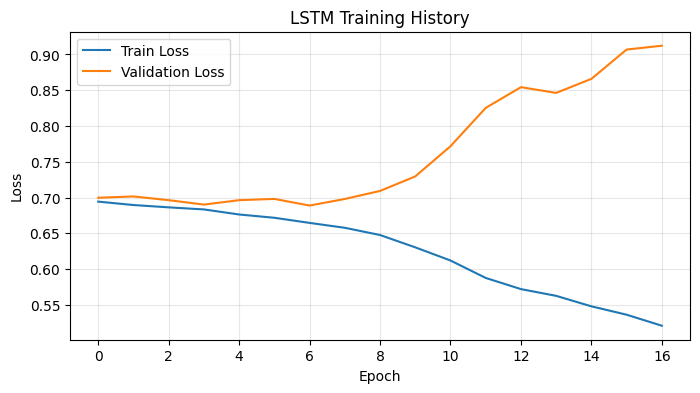


Best validation threshold for LSTM: 0.46
Best_Threshold       0.460000
Accuracy             0.457023
Balanced_Accuracy    0.471394
Macro_F1             0.452781
Weighted_F1          0.466821
ROC_AUC              0.477388
Precision_Class_0    0.330827
Recall_Class_0       0.520710
F1_Class_0           0.404598
Precision_Class_1    0.616114
Recall_Class_1       0.422078
F1_Class_1           0.500963
dtype: float64

Classification Report:
              precision    recall  f1-score   support

         0.0       0.33      0.52      0.40       169
         1.0       0.62      0.42      0.50       308

    accuracy                           0.46       477
   macro avg       0.47      0.47      0.45       477
weighted avg       0.52      0.46      0.47       477



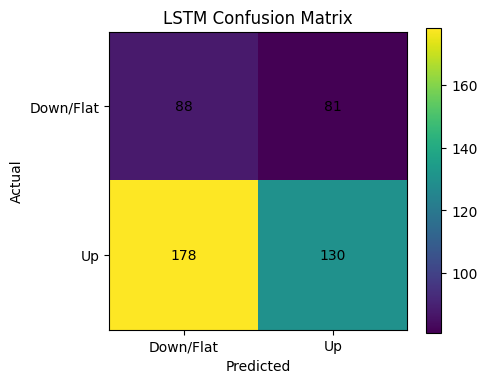


Training Transformer
Epoch 01 | Train Loss: 0.7403 | Val Loss: 0.7170
Epoch 02 | Train Loss: 0.7089 | Val Loss: 0.7051
Epoch 03 | Train Loss: 0.7094 | Val Loss: 0.6935
Epoch 04 | Train Loss: 0.7046 | Val Loss: 0.7044
Epoch 05 | Train Loss: 0.7025 | Val Loss: 0.6896
Epoch 06 | Train Loss: 0.6963 | Val Loss: 0.6919
Epoch 07 | Train Loss: 0.6961 | Val Loss: 0.7016
Epoch 08 | Train Loss: 0.6974 | Val Loss: 0.7167
Epoch 09 | Train Loss: 0.6915 | Val Loss: 0.6932
Epoch 10 | Train Loss: 0.6862 | Val Loss: 0.6986
Epoch 11 | Train Loss: 0.6856 | Val Loss: 0.7093
Epoch 12 | Train Loss: 0.6866 | Val Loss: 0.7046
Epoch 13 | Train Loss: 0.6863 | Val Loss: 0.7122
Epoch 14 | Train Loss: 0.6797 | Val Loss: 0.6931
Epoch 15 | Train Loss: 0.6752 | Val Loss: 0.6939
Early stopping triggered.


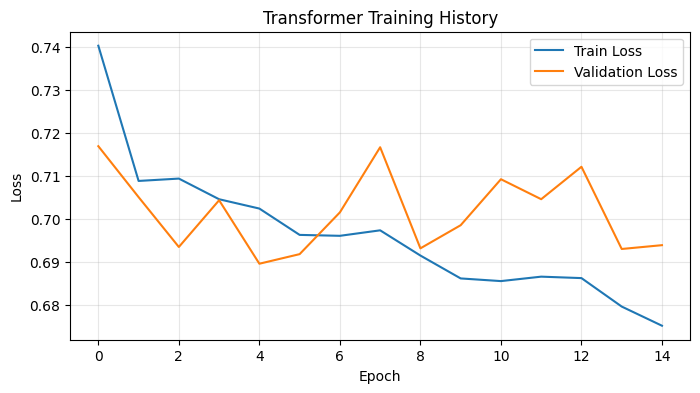


Best validation threshold for Transformer: 0.46
Best_Threshold       0.460000
Accuracy             0.607966
Balanced_Accuracy    0.526858
Macro_F1             0.518086
Weighted_F1          0.578733
ROC_AUC              0.538961
Precision_Class_0    0.411765
Recall_Class_0       0.248521
F1_Class_0           0.309963
Precision_Class_1    0.661333
Recall_Class_1       0.805195
F1_Class_1           0.726208
dtype: float64

Classification Report:
              precision    recall  f1-score   support

         0.0       0.41      0.25      0.31       169
         1.0       0.66      0.81      0.73       308

    accuracy                           0.61       477
   macro avg       0.54      0.53      0.52       477
weighted avg       0.57      0.61      0.58       477



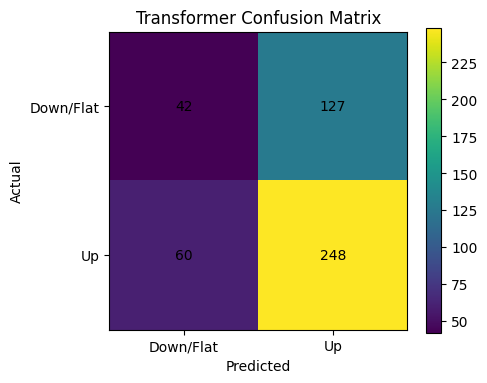


Training Hybrid_LSTM_Transformer
Epoch 01 | Train Loss: 0.6984 | Val Loss: 0.6921
Epoch 02 | Train Loss: 0.6960 | Val Loss: 0.6913
Epoch 03 | Train Loss: 0.6958 | Val Loss: 0.7071
Epoch 04 | Train Loss: 0.6952 | Val Loss: 0.7024
Epoch 05 | Train Loss: 0.6938 | Val Loss: 0.6963
Epoch 06 | Train Loss: 0.6903 | Val Loss: 0.7048
Epoch 07 | Train Loss: 0.6836 | Val Loss: 0.7075
Epoch 08 | Train Loss: 0.6777 | Val Loss: 0.7059
Epoch 09 | Train Loss: 0.6700 | Val Loss: 0.7212
Epoch 10 | Train Loss: 0.6571 | Val Loss: 0.7126
Epoch 11 | Train Loss: 0.6518 | Val Loss: 0.7320
Epoch 12 | Train Loss: 0.6453 | Val Loss: 0.7623
Early stopping triggered.


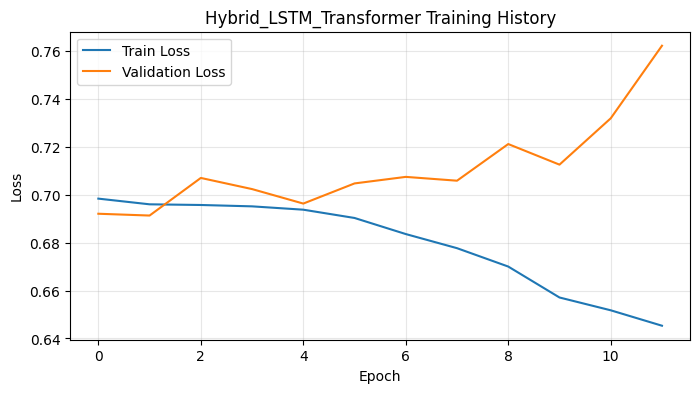


Best validation threshold for Hybrid_LSTM_Transformer: 0.48
Best_Threshold       0.480000
Accuracy             0.651992
Balanced_Accuracy    0.539585
Macro_F1             0.506494
Weighted_F1          0.584580
ROC_AUC              0.542861
Precision_Class_0    0.530612
Recall_Class_0       0.153846
F1_Class_0           0.238532
Precision_Class_1    0.665888
Recall_Class_1       0.925325
F1_Class_1           0.774457
dtype: float64

Classification Report:
              precision    recall  f1-score   support

         0.0       0.53      0.15      0.24       169
         1.0       0.67      0.93      0.77       308

    accuracy                           0.65       477
   macro avg       0.60      0.54      0.51       477
weighted avg       0.62      0.65      0.58       477



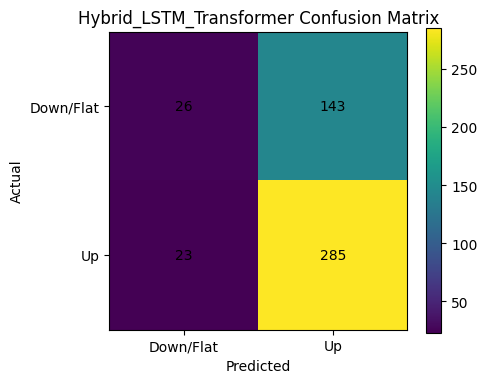

In [21]:
# Model Evaluation
all_histories = {}
all_results = {}
all_predictions = {}

for model_name, model in models.items():
    print("\n" + "=" * 70)
    print(f"Training {model_name}")
    print("=" * 70)

    trained_model, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=40,
        lr=5e-4,
        weight_decay=1e-4,
        patience=10
    )

    all_histories[model_name] = history
    plot_history(history, f"{model_name} Training History")

    val_probs, val_true = get_probabilities(trained_model, val_loader)
    best_threshold, best_macro_f1 = tune_threshold_macro_f1(val_true, val_probs)

    test_probs, test_true = get_probabilities(trained_model, test_loader)
    metrics, test_preds = compute_metrics(test_true, test_probs, threshold=best_threshold)

    all_results[model_name] = {
        "Best_Threshold": best_threshold,
        **metrics
    }

    all_predictions[model_name] = {
        "model": trained_model,
        "y_true": test_true,
        "probs": test_probs,
        "preds": test_preds
    }

    print(f"\nBest validation threshold for {model_name}: {best_threshold:.2f}")
    print(pd.Series(all_results[model_name]))
    print("\nClassification Report:")
    print(classification_report(test_true, test_preds, zero_division=0))

    plot_conf_matrix(test_true, test_preds, f"{model_name} Confusion Matrix")

In [22]:
# Model Performance Comparison
results_df = pd.DataFrame(all_results).T.sort_values(by="Macro_F1", ascending=False)
print("\nFinal Model Comparison:")
display(results_df)


Final Model Comparison:


,Best_Threshold,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1,ROC_AUC,Precision_Class_0,Recall_Class_0,F1_Class_0,Precision_Class_1,Recall_Class_1,F1_Class_1
Transformer,0.46,0.607966,0.526858,0.518086,0.578733,0.538961,0.411765,0.248521,0.309963,0.661333,0.805195,0.726208
Hybrid_LSTM_Transformer,0.48,0.651992,0.539585,0.506494,0.584580,0.542861,0.530612,0.153846,0.238532,0.665888,0.925325,0.774457
LSTM,0.46,0.457023,0.471394,0.452781,0.466821,0.477388,0.330827,0.520710,0.404598,0.616114,0.422078,0.500963


In [23]:
results_df.columns

Index(['Best_Threshold', 'Accuracy', 'Balanced_Accuracy', 'Macro_F1',
       'Weighted_F1', 'ROC_AUC', 'Precision_Class_0', 'Recall_Class_0',
       'F1_Class_0', 'Precision_Class_1', 'Recall_Class_1', 'F1_Class_1'],
      dtype='object')

In [24]:
# Performance under High Volatility
vol_threshold = np.nanpercentile(test_vol, 75)
volatile_mask = test_vol >= vol_threshold

volatility_results = []

for model_name, pred_dict in all_predictions.items():
    y_true_vol = pred_dict["y_true"][volatile_mask]
    probs_vol = pred_dict["probs"][volatile_mask]
    thr = all_results[model_name]["Best_Threshold"]

    if len(np.unique(y_true_vol)) > 1:
        metrics_vol, preds_vol = compute_metrics(y_true_vol, probs_vol, threshold=thr)
        metrics_vol["Model"] = model_name
        metrics_vol["Samples"] = len(y_true_vol)
        volatility_results.append(metrics_vol)

volatility_df = pd.DataFrame(volatility_results).set_index("Model")
print("\nPerformance during high-volatility periods:")
display(volatility_df)


Performance during high-volatility periods:


,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1,ROC_AUC,Precision_Class_0,Recall_Class_0,F1_Class_0,Precision_Class_1,Recall_Class_1,F1_Class_1,Samples
Model,,,,,,,,,,,,
LSTM,0.491667,0.486842,0.472280,0.509367,0.424262,0.305085,0.473684,0.371134,0.672131,0.500000,0.573427,120
Transformer,0.666667,0.508986,0.462125,0.583744,0.652760,0.375000,0.078947,0.130435,0.687500,0.939024,0.793814,120
Hybrid_LSTM_Transformer,0.675000,0.557445,0.551337,0.637705,0.617137,0.473684,0.236842,0.315789,0.712871,0.878049,0.786885,120


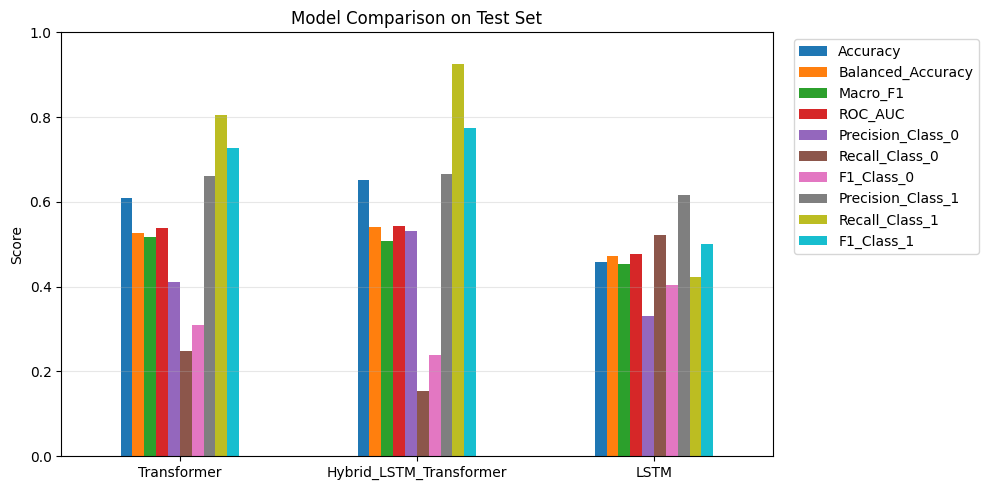

In [25]:
# Results Visualization
metric_to_plot = ['Accuracy', 'Balanced_Accuracy', 'Macro_F1', 'ROC_AUC', 'Precision_Class_0', 'Recall_Class_0', 'F1_Class_0', 'Precision_Class_1', 'Recall_Class_1', 'F1_Class_1']

results_df[metric_to_plot].plot(kind="bar", figsize=(10, 5))
plt.title("Model Comparison on Test Set")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [26]:
# Model saving
best_model_name = results_df.index[0]
best_model = all_predictions[best_model_name]["model"]

os.makedirs("saved_models", exist_ok=True)
save_path = f"saved_models/{best_model_name.lower()}_best.pth"
torch.save(best_model.state_dict(), save_path)

print(f"Best model: {best_model_name}")
print(f"Saved to: {save_path}")

Best model: Transformer
Saved to: saved_models/transformer_best.pth


In [27]:
# Prediction Analysis
best_probs = all_predictions[best_model_name]["probs"]
best_preds = all_predictions[best_model_name]["preds"]
best_true = all_predictions[best_model_name]["y_true"]

prediction_table = pd.DataFrame({
    "Date": test_dates,
    "Actual_Class": best_true.astype(int),
    "Predicted_Prob_Up": best_probs,
    "Predicted_Class": best_preds.astype(int),
    "Forward_5D_Return": test_fwd,
    "Volatility_20": test_vol
})

print("\nSample Predictions:")
display(prediction_table.head(10))


Sample Predictions:


,Date,Actual_Class,Predicted_Prob_Up,Predicted_Class,Forward_5D_Return,Volatility_20
0,2022-11-15,1,0.473330,1,0.003538,0.018222
1,2022-11-16,1,0.495834,1,0.017626,0.018239
2,2022-11-17,1,0.488787,1,0.020520,0.018092
3,2022-11-22,1,0.495258,1,0.019455,0.017272
4,2022-11-23,1,0.491971,1,0.012325,0.017144
5,2022-11-25,1,0.485007,1,0.011384,0.017055
6,2022-11-28,1,0.479762,1,0.009295,0.016819
7,2022-11-29,0,0.493147,1,-0.003542,0.016722
8,2022-11-30,0,0.478141,1,-0.035616,0.017961
9,2022-12-01,0,0.469633,1,-0.027346,0.016734


In [28]:
# Target Interpretation
print("\nHow to interpret the target:")
print("Target = 1 means the 5-trading-day forward return is positive.")
print("Target = 0 means the 5-trading-day forward return is zero or negative.")


How to interpret the target:
Target = 1 means the 5-trading-day forward return is positive.
Target = 0 means the 5-trading-day forward return is zero or negative.


In [29]:
# Download New Data
new_df = yf.download("SPY", start="2025-01-01", end="2026-01-01", auto_adjust=True)
new_df.columns = new_df.columns.get_level_values(0)

new_df = new_df.reset_index()

new_df = new_df[["Date", "Open", "High", "Low", "Close", "Volume"]]
new_df.dropna(inplace=True)

print(new_df.head())

[*********************100%***********************]  1 of 1 completed

Price       Date        Open        High         Low       Close    Volume
0     2025-01-02  580.962415  582.677525  572.199517  576.280334  50204000
1     2025-01-03  579.129057  584.126510  578.044750  583.485840  37888500
2     2025-01-06  587.744068  591.125016  585.112202  586.847046  47679400
3     2025-01-07  588.877548  589.202846  578.389734  580.213257  60393100
4     2025-01-08  580.282292  582.135415  576.832338  581.060974  47304700


In [30]:
# Feature engineering
new_df = add_features(new_df)

In [31]:
# Create Target
horizon = 5
neutral_band = 0.002

new_df["forward_return_5d"] = new_df["Close"].shift(-horizon) / new_df["Close"] - 1

new_df = new_df[(new_df["forward_return_5d"].abs() >= neutral_band)].copy()

new_df["Target"] = (new_df["forward_return_5d"] > 0).astype(int)

new_df.dropna(inplace=True)
new_df.reset_index(drop=True, inplace=True)

In [32]:
# Scaling
new_scaled = scaler.transform(new_df[feature_cols])
new_scaled = pd.DataFrame(new_scaled, columns=feature_cols)

In [33]:
# Create Sequences
X_new, y_new, new_dates, new_fwd, new_vol = make_sequences(
    new_scaled, new_df, feature_cols, "Target", sequence_length
)

In [34]:
new_dataset = TimeSeriesDataset(X_new, y_new)
new_loader = DataLoader(new_dataset, batch_size=batch_size, shuffle=False)

# Evaluate Model
new_probs, new_true = get_probabilities(best_model, new_loader)

new_metrics, new_preds = compute_metrics(
    new_true,
    new_probs,
    threshold=all_results[best_model_name]["Best_Threshold"]
)

print("New Data Performance:")
print(pd.Series(new_metrics))

New Data Performance:
Accuracy             0.554286
Balanced_Accuracy    0.454617
Macro_F1             0.454000
Weighted_F1          0.551611
ROC_AUC              0.459836
Precision_Class_0    0.224490
Recall_Class_0       0.215686
F1_Class_0           0.220000
Precision_Class_1    0.682540
Recall_Class_1       0.693548
F1_Class_1           0.688000
dtype: float64


In [35]:
# New Data Prediction Table
new_prediction_table = pd.DataFrame({
    "Date": new_dates,
    "Actual_Class": new_true.astype(int),
    "Predicted_Prob_Up": new_probs,
    "Predicted_Class": new_preds.astype(int),
    "Forward_5D_Return": new_fwd,
    "Volatility_20": new_vol
})

print("Sample Predictions on New Data:")
display(new_prediction_table.head(15))

Sample Predictions on New Data:


,Date,Actual_Class,Predicted_Prob_Up,Predicted_Class,Forward_5D_Return,Volatility_20
0,2025-04-04,1,0.495559,1,0.056721,0.020239
1,2025-04-07,1,0.496265,1,0.068877,0.019672
2,2025-04-08,1,0.486612,1,0.082843,0.019806
3,2025-04-09,0,0.501237,1,-0.041851,0.031634
4,2025-04-10,1,0.457517,0,0.003489,0.033000
5,2025-04-11,0,0.475921,1,-0.037570,0.032905
6,2025-04-14,0,0.482037,1,-0.022017,0.032939
7,2025-04-15,0,0.490994,1,-0.004074,0.032873
8,2025-04-16,1,0.491161,1,0.040007,0.033051
9,2025-04-17,1,0.510996,1,0.046029,0.033067


In [36]:
# Adding text labels for easier interpretation
new_prediction_table["Actual_Label"] = new_prediction_table["Actual_Class"].map({1: "Up", 0: "Down"})
new_prediction_table["Predicted_Label"] = new_prediction_table["Predicted_Class"].map({1: "Up", 0: "Down"})

print("Readable Predictions on New Data:")
display(
    new_prediction_table[
        ["Date", "Actual_Label", "Predicted_Label", "Predicted_Prob_Up", "Forward_5D_Return", "Volatility_20"]
    ].head(15)
)

Readable Predictions on New Data:


,Date,Actual_Label,Predicted_Label,Predicted_Prob_Up,Forward_5D_Return,Volatility_20
0,2025-04-04,Up,Up,0.495559,0.056721,0.020239
1,2025-04-07,Up,Up,0.496265,0.068877,0.019672
2,2025-04-08,Up,Up,0.486612,0.082843,0.019806
3,2025-04-09,Down,Up,0.501237,-0.041851,0.031634
4,2025-04-10,Up,Down,0.457517,0.003489,0.033000
5,2025-04-11,Down,Up,0.475921,-0.037570,0.032905
6,2025-04-14,Down,Up,0.482037,-0.022017,0.032939
7,2025-04-15,Down,Up,0.490994,-0.004074,0.032873
8,2025-04-16,Up,Up,0.491161,0.040007,0.033051
9,2025-04-17,Up,Up,0.510996,0.046029,0.033067


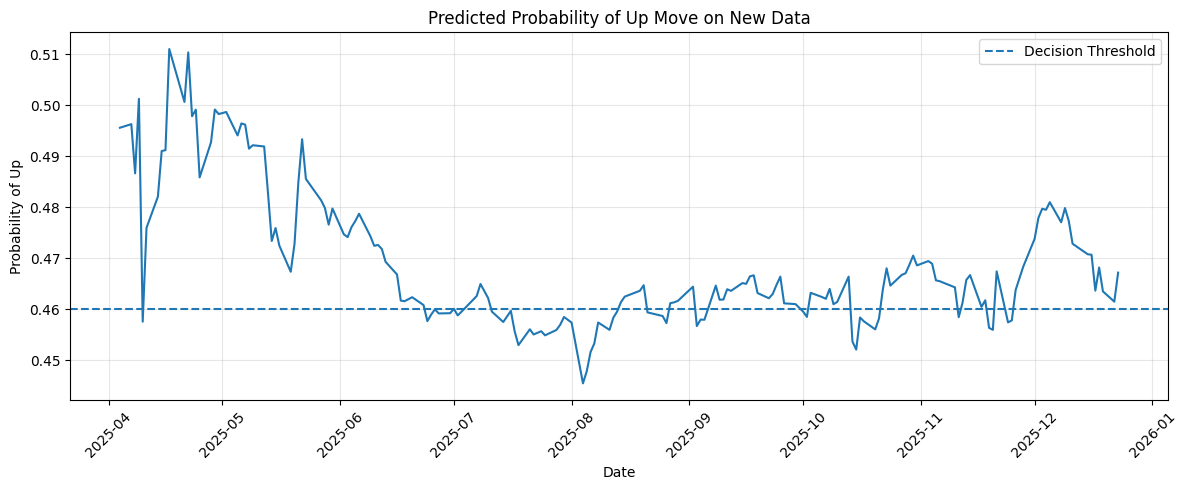

In [37]:
# Plot predicted probability of upward movement over time
plt.figure(figsize=(12, 5))
plt.plot(new_prediction_table["Date"], new_prediction_table["Predicted_Prob_Up"])
plt.axhline(all_results[best_model_name]["Best_Threshold"], linestyle="--", label="Decision Threshold")
plt.title("Predicted Probability of Up Move on New Data")
plt.xlabel("Date")
plt.ylabel("Probability of Up")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Deployment Artifacts for Hugging Face Streamlit App

In [38]:
import os
import json
import joblib

# Creating folder for deployment artifacts
os.makedirs("saved_models", exist_ok=True)

# Saving fitted scaler
joblib.dump(scaler, "saved_models/scaler.pkl")

# Saving model/pipeline configuration
model_config = {
    "best_model_name": best_model_name,
    "feature_cols": feature_cols,
    "sequence_length": sequence_length,
    "best_threshold": float(all_results[best_model_name]["Best_Threshold"]),
    "input_dim": len(feature_cols)
}

with open("saved_models/model_config.json", "w") as f:
    json.dump(model_config, f, indent=4)

print("Deployment artifacts saved successfully.")
print("Saved files:")
print("- saved_models/scaler.pkl")
print("- saved_models/model_config.json")

Deployment artifacts saved successfully.
Saved files:
- saved_models/scaler.pkl
- saved_models/model_config.json


In [39]:
print("Files inside saved_models folder:")
for file_name in os.listdir("saved_models"):
    print("-", file_name)

Files inside saved_models folder:
- transformer_best.pth
- model_config.json
- scaler.pkl
